## Imports

In [1]:
import os
import sys
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from tabulate import tabulate

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from utils.tools import (
    compute_lagged_correlations,
    find_dominant_lagged_pairs,
    plot_pearson_heatmap,
    report_correlation_distribution,
    classify_anomalies_multi,
    summarize,
    collect_seg_stats_multi,
    plot_threshold_sensitivity,
    print_dominant_pairs,
    compute_univariate_intensity,
    plot_univariate_intensity_distribution
)

## Loading

In [2]:
path = kagglehub.dataset_download("mgusat/smd-onmiad")

print("Path to dataset files:", path)

Path to dataset files: /Users/marcp/.cache/kagglehub/datasets/mgusat/smd-onmiad/versions/1


In [3]:
print("Contents of the dataset directory:", os.listdir(path))
print(os.listdir(path + "/ServerMachineDataset"))

for machine_dir in os.listdir(path + "/ServerMachineDataset"):
    a = os.path.join(path + "/ServerMachineDataset", machine_dir)
    if not os.path.isdir(a):
        continue
    print(f"Contents of {a}:", os.listdir(a))

Contents of the dataset directory: ['ServerMachineDataset']
['LICENSE', 'test', 'test_label', 'interpretation_label', 'train']
Contents of /Users/marcp/.cache/kagglehub/datasets/mgusat/smd-onmiad/versions/1/ServerMachineDataset/test: ['machine-1-5.txt', 'machine-3-11.txt', 'machine-3-7.txt', 'machine-3-6.txt', 'machine-3-10.txt', 'machine-1-4.txt', 'machine-1-6.txt', 'machine-3-4.txt', 'machine-3-5.txt', 'machine-1-7.txt', 'machine-1-3.txt', 'machine-3-1.txt', 'machine-1-2.txt', 'machine-3-2.txt', 'machine-3-3.txt', 'machine-1-1.txt', 'machine-2-4.txt', 'machine-2-5.txt', 'machine-2-7.txt', 'machine-2-6.txt', 'machine-2-2.txt', 'machine-2-3.txt', 'machine-2-1.txt', 'machine-2-8.txt', 'machine-2-9.txt', 'machine-3-8.txt', 'machine-3-9.txt', 'machine-1-8.txt']
Contents of /Users/marcp/.cache/kagglehub/datasets/mgusat/smd-onmiad/versions/1/ServerMachineDataset/test_label: ['machine-1-5.txt', 'machine-3-11.txt', 'machine-3-7.txt', 'machine-3-6.txt', 'machine-3-10.txt', 'machine-1-4.txt', '

In [4]:
data_path = Path(path) / "ServerMachineDataset"
machine_names = sorted([f.stem for f in (data_path / "train").glob("*.txt")])
print(f"Number of machines: {len(machine_names)}")

train_data_list = []
test_data_list = []
test_labels_list = []

for machine_name in tqdm(machine_names, desc="Loading machines"):
    train_data = np.loadtxt(data_path / "train" / f"{machine_name}.txt", delimiter=",")
    test_data = np.loadtxt(data_path / "test" / f"{machine_name}.txt", delimiter=",")
    test_labels = np.loadtxt(data_path / "test_label" / f"{machine_name}.txt", delimiter=",")

    #mean = train_data.mean(axis=0)
    #std = train_data.std(axis=0) + 1e-8  # Prevent division by zero
    #train_norm = (train_data - mean) / std  # we use the train stats to normalize both train and test to avoid data leakage from test
    #test_norm = (test_data - mean) / std  # same here

    train_data_list.append(train_data.astype(np.float32))
    test_data_list.append(test_data.astype(np.float32))
    test_labels_list.append(test_labels.astype(np.float32))

input_dim = train_data_list[0].shape[1]
print(f"Input dim: {input_dim}")

Number of machines: 28


Loading machines: 100%|██████████| 28/28 [00:01<00:00, 18.71it/s]

Input dim: 38


In [5]:
print(len(train_data_list[18]))

23692


In [6]:
train_df = pd.DataFrame(np.vstack(train_data_list))
test_df = pd.DataFrame(np.vstack(test_data_list))
test_label_df = pd.DataFrame(np.hstack(test_labels_list))

## Basic infos

In [7]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
0,0.032258,0.039195,0.027871,0.024390,0.0,0.915385,0.343691,0.0,0.020011,0.000122,...,0.0,0.004298,0.029993,0.022131,0.0,0.000045,0.034677,0.034747,0.0,0.0
1,0.043011,0.048729,0.033445,0.025552,0.0,0.915385,0.344633,0.0,0.019160,0.001722,...,0.0,0.004298,0.030041,0.028821,0.0,0.000045,0.035763,0.035833,0.0,0.0
2,0.043011,0.034958,0.032330,0.025552,0.0,0.915385,0.344633,0.0,0.020011,0.000122,...,0.0,0.004298,0.026248,0.021101,0.0,0.000045,0.033012,0.033082,0.0,0.0
3,0.032258,0.028602,0.030100,0.024390,0.0,0.912821,0.342750,0.0,0.021289,0.000000,...,0.0,0.004298,0.030169,0.025733,0.0,0.000022,0.035112,0.035182,0.0,0.0
4,0.032258,0.019068,0.026756,0.023229,0.0,0.912821,0.342750,0.0,0.018734,0.000000,...,0.0,0.004298,0.027240,0.022645,0.0,0.000034,0.033447,0.033517,0.0,0.0


In [8]:
train_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
count,708405.000000,708405.000000,708405.000000,708405.000000,708405.000000,708405.000000,708405.000000,708405.0,708405.000000,708405.000000,...,708405.000000,708405.000000,708405.000000,708405.000000,708405.000000,708405.000000,708405.000000,708405.000000,708405.000000,708405.000000
mean,0.135608,0.070325,0.081224,0.095481,0.263753,0.722551,0.394186,0.0,0.020008,0.001013,...,0.000016,0.100355,0.191688,0.105285,0.035761,0.057729,0.214860,0.210742,0.016665,0.009591
std,0.137689,0.110758,0.128474,0.157457,0.415750,0.294859,0.323408,0.0,0.051456,0.010996,...,0.003382,0.139201,0.186920,0.148773,0.083626,0.107499,0.204549,0.206821,0.071080,0.059371
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.032258,0.003363,0.004544,0.005624,0.000000,0.452556,0.147541,0.0,0.000187,0.000000,...,0.000000,0.000605,0.042095,0.000000,0.000000,0.009009,0.045317,0.040404,0.000000,0.000000
50%,0.090909,0.023305,0.029070,0.031166,0.000000,0.859100,0.285954,0.0,0.003787,0.000000,...,0.000000,0.021505,0.136832,0.047349,0.000000,0.022989,0.155863,0.147628,0.000000,0.000000
75%,0.193548,0.081597,0.088327,0.096535,0.652174,0.983467,0.683879,0.0,0.016135,0.000002,...,0.000000,0.172414,0.294752,0.147436,0.023256,0.051064,0.314286,0.314536,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.888497,0.888497


## Data exploration

In [9]:
#check if all columns are min-max normalized
print("Min values:\n", train_df.min())
print("Max values:\n", train_df.max())

Min values:
 0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
15    0.0
16    0.0
17    0.0
18    0.0
19    0.0
20    0.0
21    0.0
22    0.0
23    0.0
24    0.0
25    0.0
26    0.0
27    0.0
28    0.0
29    0.0
30    0.0
31    0.0
32    0.0
33    0.0
34    0.0
35    0.0
36    0.0
37    0.0
dtype: float32
Max values:
 0     1.000000
1     1.000000
2     1.000000
3     1.000000
4     1.000000
5     1.000000
6     1.000000
7     0.000000
8     1.000000
9     1.000000
10    1.000000
11    1.000000
12    1.000000
13    1.000000
14    1.000000
15    1.000000
16    1.000000
17    1.000000
18    1.000000
19    1.000000
20    1.000000
21    1.000000
22    1.000000
23    1.000000
24    1.000000
25    1.000000
26    1.000000
27    1.000000
28    1.000000
29    1.000000
30    1.000000
31    1.000000
32    1.000000
33    1.000000
34    1.000000
35    1.000000
36    0.888497
37    0.888497
dtype: fl

In [10]:
train_df.isnull().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    0
35    0
36    0
37    0
dtype: int64

In [11]:
for i, machine_name in enumerate(machine_names):
    n_train = train_data_list[i].shape[0]
    n_test = test_data_list[i].shape[0]
    n_labels = test_labels_list[i].shape[0]
    print(f"Machine {machine_name}: train_set={n_train}, test_set={n_test}, test_labels={n_labels}")

Machine machine-1-1: train_set=28479, test_set=28479, test_labels=28479
Machine machine-1-2: train_set=23694, test_set=23694, test_labels=23694
Machine machine-1-3: train_set=23702, test_set=23703, test_labels=23703
Machine machine-1-4: train_set=23706, test_set=23707, test_labels=23707
Machine machine-1-5: train_set=23705, test_set=23706, test_labels=23706
Machine machine-1-6: train_set=23688, test_set=23689, test_labels=23689
Machine machine-1-7: train_set=23697, test_set=23697, test_labels=23697
Machine machine-1-8: train_set=23698, test_set=23699, test_labels=23699
Machine machine-2-1: train_set=23693, test_set=23694, test_labels=23694
Machine machine-2-2: train_set=23699, test_set=23700, test_labels=23700
Machine machine-2-3: train_set=23688, test_set=23689, test_labels=23689
Machine machine-2-4: train_set=23689, test_set=23689, test_labels=23689
Machine machine-2-5: train_set=23688, test_set=23689, test_labels=23689
Machine machine-2-6: train_set=28743, test_set=28743, test_label

In [12]:
# Sum of all entries for all machines of test_labels
a = 0
for i, machine_name in enumerate(machine_names):
    a += test_labels_list[i].shape[0]
a

708420

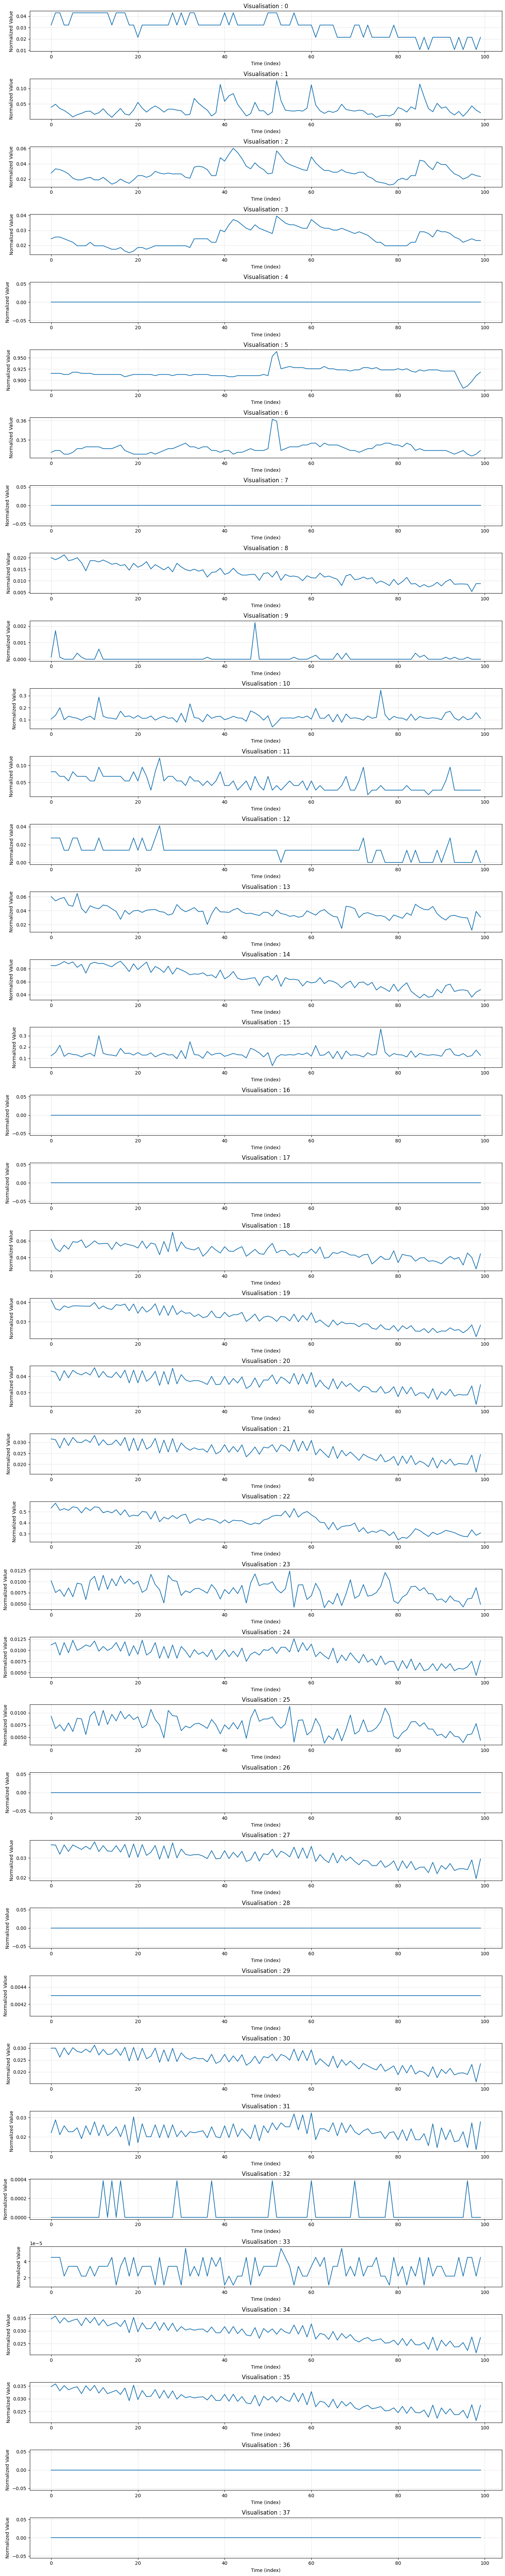

In [13]:
num_features = len(train_df.columns)

plt.figure(figsize=(15, num_features * 2))

for i, feature in enumerate(train_df.columns):
    plt.subplot(num_features, 1, i + 1)
    plt.plot(train_df[feature][:100])
    
    plt.title(f"Visualisation : {feature}")
    plt.xlabel('Time (index)')
    plt.ylabel('Normalized Value')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Correlation analysis on normal data

Since SMD is organized by machine (with machines likely following different distributions), we will process it machine by machine.

Machine are therefore treated as separate segments.

In [14]:
all_clean = all(np.isnan(a).sum() == 0 for a in train_data_list)
print("NaN in train_data_list:", not all_clean)

NaN in train_data_list: False


In [15]:
max_lag = 192
L_min = 2 * max_lag

segments = [arr for arr in train_data_list if len(arr) >= L_min]
print(f"Kept machines (L >= {L_min}): {len(segments)}/{len(train_data_list)}")

C = segments[0].shape[1]
features = [str(i) for i in range(C)]
seg_lengths = [len(s) for s in segments]
print(f"min={min(seg_lengths)}, max={max(seg_lengths)}, total={sum(seg_lengths)}")

Kept machines (L >= 384): 28/28
min=23687, max=28743, total=708405


In [16]:
lagged_corrs = compute_lagged_correlations(segments, max_lag=max_lag, progress=True)

Segments (Spearman): 100%|██████████| 28/28 [00:14<00:00,  1.92it/s]


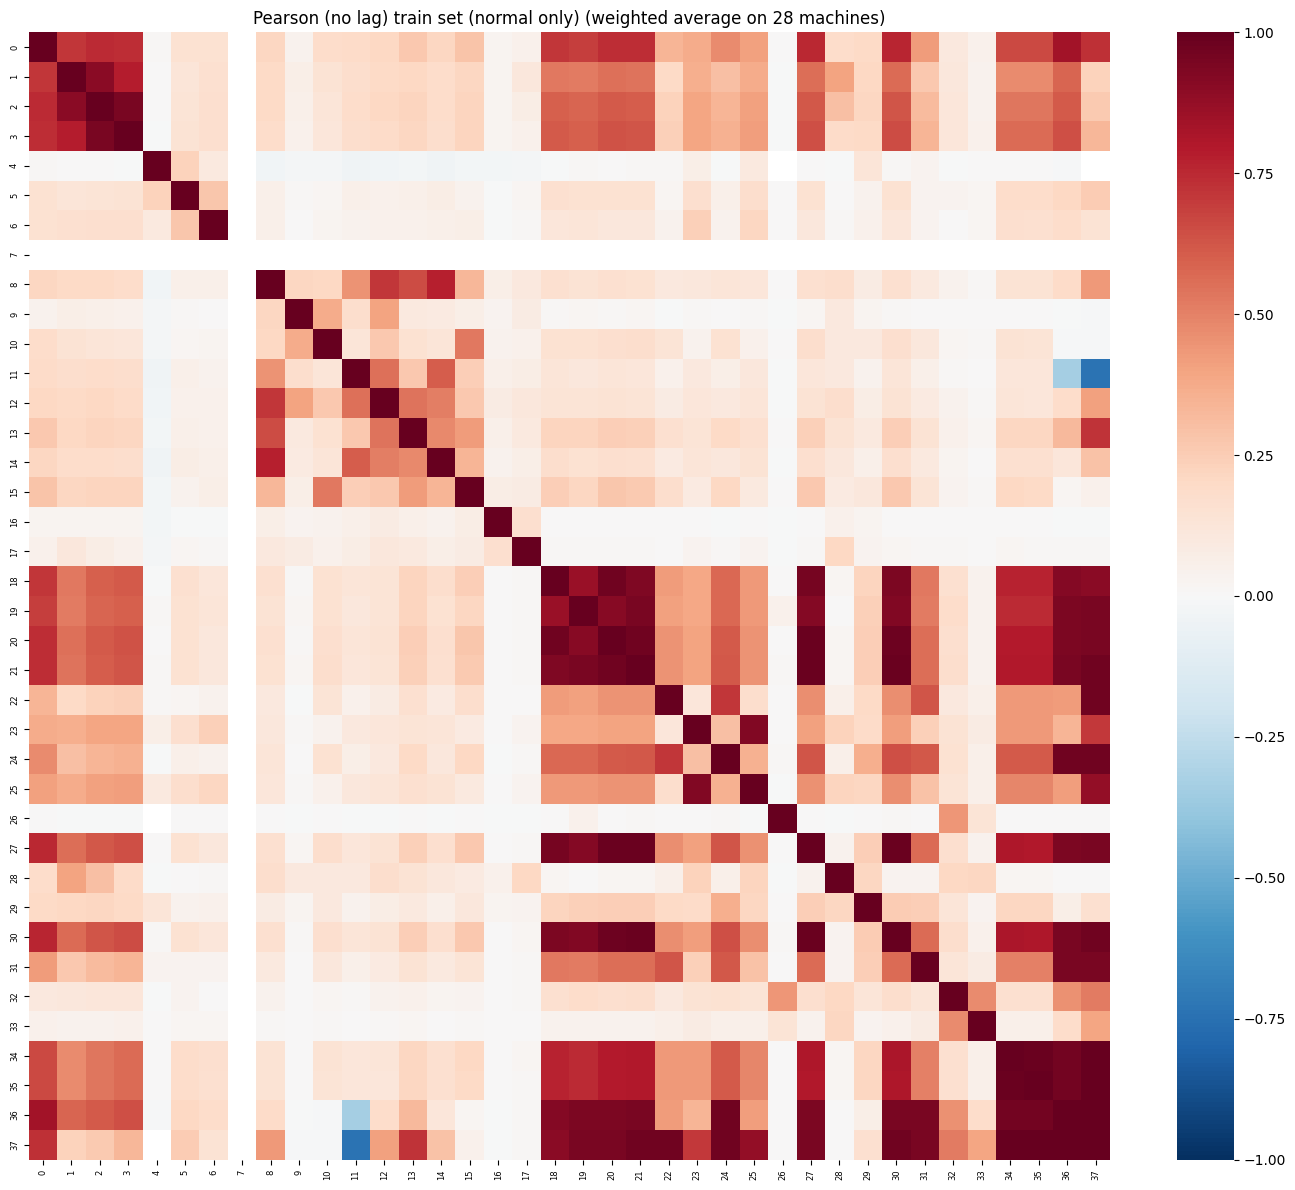

In [17]:
pearson_matrix_mean = lagged_corrs['pearson'][:, :, max_lag]
plot_pearson_heatmap(
    pearson_matrix_mean, features,
    title=f"Pearson (no lag) train set (normal only) (weighted average on {len(segments)} machines)",
)

In [18]:
print("|r| distribution (without the diagonal):")
report_correlation_distribution(pearson_matrix_mean)

|r| distribution (without the diagonal):
Total pairs: 664
  Pairs with |r| > 0.3: 189/664 (28.5%)
  Pairs with |r| > 0.5: 124/664 (18.7%)
  Pairs with |r| > 0.7: 71/664 (10.7%)


In [19]:
pairs_info = find_dominant_lagged_pairs(lagged_corrs, max_lag=max_lag, threshold=0.5)
print("Pairs with dominant lagged correlation (|r(best_lag)| > 0.5 and > |r(0)|):")
print(f"Total pairs: {len(pairs_info)}")

feature_names = [f"Feature {i}" for i in range(C)]
print_dominant_pairs(pairs_info, feature_names=feature_names)

Pairs with dominant lagged correlation (|r(best_lag)| > 0.5 and > |r(0)|):
Total pairs: 280
Total pairs: 280
 Feature 1 - Feature 2 : r(0)=+0.900  r(+1)=+0.902  [pearson]
 Feature 3 - Feature 36: r(0)=+0.876  r(-24)=+0.888  [spearman]
 Feature 2 - Feature 36: r(0)=+0.881  r(-4)=+0.883  [spearman]
 Feature 0 - Feature 3 : r(0)=+0.835  r(+10)=+0.844  [spearman]
 Feature 2 - Feature 37: r(0)=+0.840  r(-2)=+0.842  [spearman]
 Feature 3 - Feature 37: r(0)=+0.835  r(-7)=+0.839  [spearman]
 Feature 3 - Feature 30: r(0)=+0.828  r(-10)=+0.836  [spearman]
 Feature 3 - Feature 27: r(0)=+0.825  r(-10)=+0.832  [spearman]
 Feature 0 - Feature 2 : r(0)=+0.825  r(+1)=+0.827  [spearman]
 Feature 3 - Feature 21: r(0)=+0.820  r(-10)=+0.827  [spearman]
 Feature 3 - Feature 20: r(0)=+0.817  r(-10)=+0.824  [spearman]
 Feature 3 - Feature 19: r(0)=+0.808  r(-10)=+0.816  [spearman]
 Feature 2 - Feature 30: r(0)=+0.809  r(-1)=+0.810  [spearman]
 Feature 2 - Feature 27: r(0)=+0.806  r(-1)=+0.806  [spearman]
 Fe

## Anomaly analysis

In [20]:
n_train = sum(len(a) for a in train_data_list)
n_test = sum(len(a) for a in test_data_list)
n_anom = sum(int(l.sum()) for l in test_labels_list)
dim = train_data_list[0].shape[1]

print(f"Dimension: {dim}")
print(f"Train Size: {n_train}")
print(f"Test (labeled): {n_test}")
print(f"Anomaly Ratio (%): {100.0 * n_anom / n_test:.2f}")

Dimension: 38
Train Size: 708405
Test (labeled): 708420
Anomaly Ratio (%): 4.16


In [21]:
df_long, df_short = classify_anomalies_multi(
    test_arrays=test_data_list,
    label_arrays=test_labels_list,
    names=machine_names,
    train_arrays=train_data_list,
    pairs_info=pairs_info,
    id_col='machine',
)
summarize(df_long, df_short)

Counts per method (long segments):
+----------------------+-----------+------------+--------+
| label                |   pearson |   spearman |   dcor |
|----------------------+-----------+------------+--------|
| UNIVARIATE           |         0 |          0 |      0 |
| BOTH                 |       176 |        176 |    176 |
| CROSS-CHANNEL        |         0 |          0 |      0 |
| UNDETECTED           |         0 |          0 |      0 |
| INSUFFICIENT_CONTEXT |         1 |          1 |      1 |
+----------------------+-----------+------------+--------+

Counts (short segments, < min_len points):
+----------------------+---------+
| label                |   count |
|----------------------+---------|
| UNIVARIATE           |     148 |
| UNDETECTED           |       1 |
| INSUFFICIENT_CONTEXT |       1 |
+----------------------+---------+


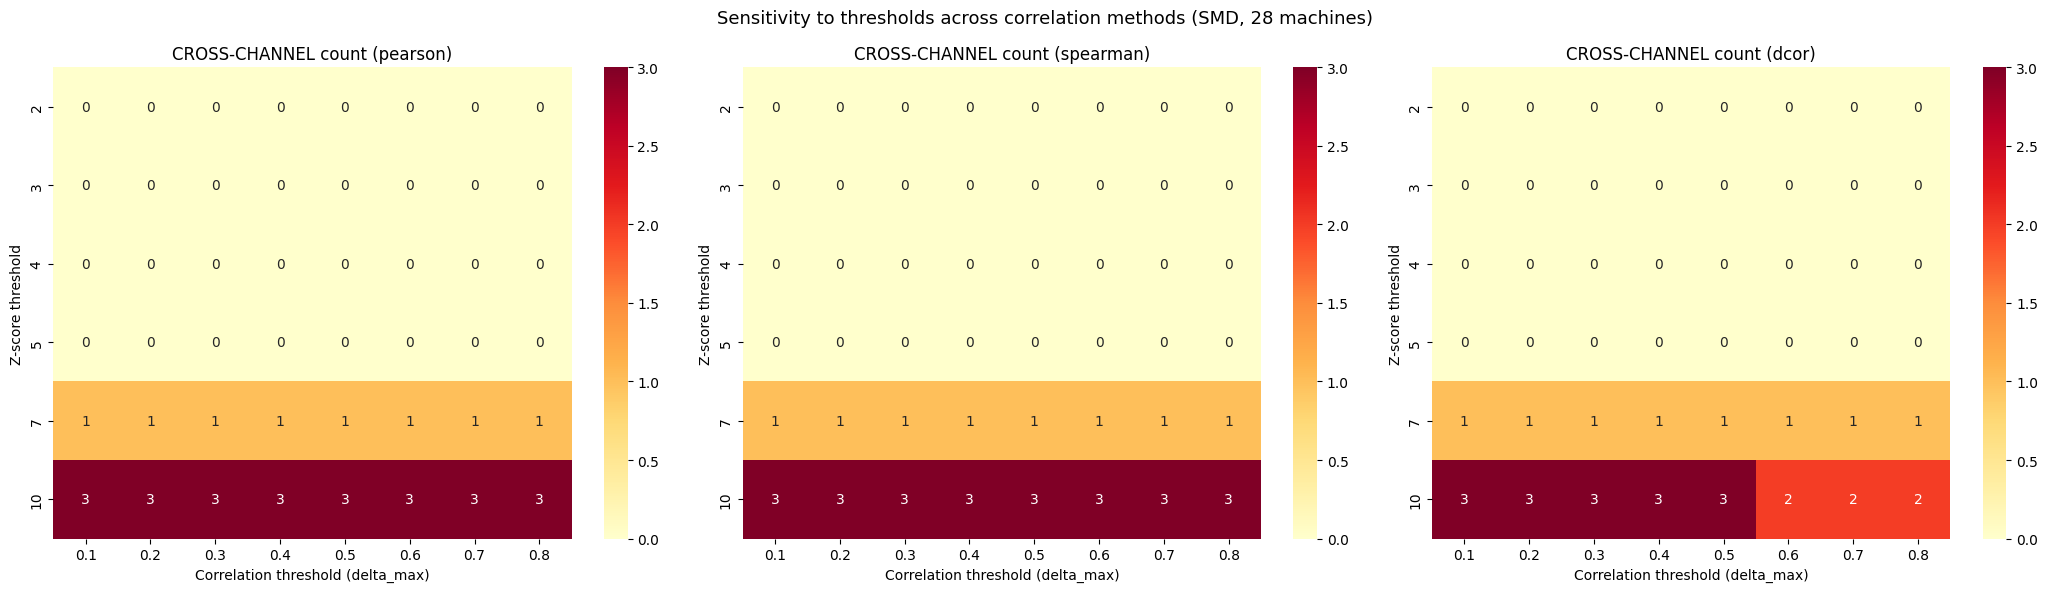

{'pearson': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1],
        [3, 3, 3, 3, 3, 3, 3, 3]]),
 'spearman': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1],
        [3, 3, 3, 3, 3, 3, 3, 3]]),
 'dcor': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1],
        [3, 3, 3, 3, 3, 2, 2, 2]])}

In [22]:
seg_stats = collect_seg_stats_multi(
    test_arrays=test_data_list,
    label_arrays=test_labels_list,
    train_arrays=train_data_list,
    pairs_info=pairs_info,
)
plot_threshold_sensitivity(seg_stats, title="Sensitivity to thresholds across correlation methods (SMD, 28 machines)")

The single CROSS-CHANNEL at $\tau_z = 10$ is a segment with a clear univariate deviation (max_z between 7 and 10) that only loses its UNIVARIATE label when the threshold is set unreasonably high (10).

In [23]:
intensity_df, summary = compute_univariate_intensity(
    test_arrays=test_data_list, label_arrays=test_labels_list,
    names=machine_names, train_arrays=train_data_list,
    id_col='machine',
)
print(tabulate(summary, headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False))

+--------------+------------------+--------------------+-----------------+
|   n_segments |   mean_ratio_uni |   median_ratio_uni |   min_ratio_uni |
|--------------+------------------+--------------------+-----------------|
|      176.000 |            0.790 |              0.893 |           0.066 |
+--------------+------------------+--------------------+-----------------+


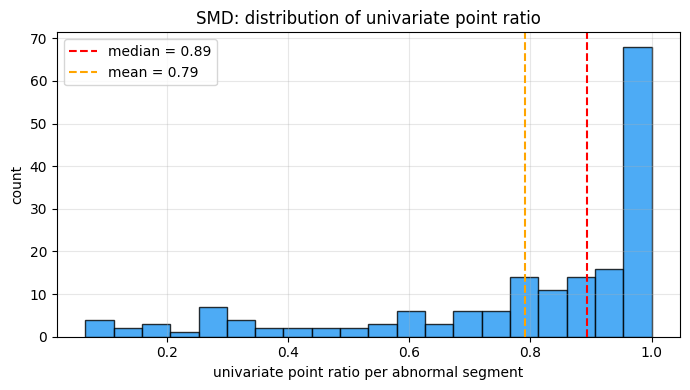

In [24]:
plot_univariate_intensity_distribution(intensity_df, 'SMD')

BOTH segments (union over pearson/spearman/dcor): 176
Machines containing >=1 BOTH segment: 28 / 28
Anomalous points retained: 28812 / 29444 (97.9%)
+--------------+------------------+--------------------+-----------------+
|   n_segments |   mean_ratio_uni |   median_ratio_uni |   min_ratio_uni |
|--------------+------------------+--------------------+-----------------|
|      176.000 |            0.789 |              0.887 |           0.066 |
+--------------+------------------+--------------------+-----------------+


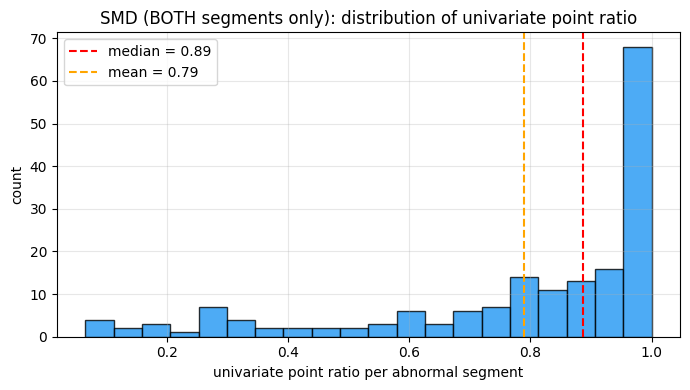

In [25]:
both_mask = (
    (df_long['lab_pearson'] == 'BOTH') |
    (df_long['lab_spearman'] == 'BOTH') |
    (df_long['lab_dcor'] == 'BOTH')
)
df_both = df_long.loc[both_mask, ['machine', 'start', 'end']]

ev_both_list = []
for k, m in enumerate(machine_names):
    ev_both = np.zeros_like(test_labels_list[k])
    for _, r in df_both[df_both['machine'] == m].iterrows():
        ev_both[int(r['start']):int(r['end'])] = 1
    ev_both_list.append(ev_both)

n_seg_both = len(df_both)
n_pts_both = int(sum(int(e.sum()) for e in ev_both_list))
n_pts_total = int(sum(int(l.sum()) for l in test_labels_list))
n_machines_both = int(df_both['machine'].nunique())

print(f"BOTH segments (union over pearson/spearman/dcor): {n_seg_both}")
print(f"Machines containing >=1 BOTH segment: {n_machines_both} / {len(machine_names)}")
print(f"Anomalous points retained: {n_pts_both} / {n_pts_total} ({100.0 * n_pts_both / max(n_pts_total, 1):.1f}%)")

intensity_df_both, summary_both = compute_univariate_intensity(
    test_arrays=test_data_list,
    label_arrays=ev_both_list,
    names=machine_names,
    train_arrays=train_data_list,
    id_col='machine',
)
print(tabulate(summary_both, headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False))

plot_univariate_intensity_distribution(intensity_df_both, 'SMD (BOTH segments only)')